In [1]:
import h5py
import numpy as np

with h5py.File("tree.hdf5", "r") as f:
    print(list(f.keys()))
SNAP = 80
with h5py.File("tree.hdf5", "r") as f:

    snap = f["SnapNum"][:]
    subfind = f["SubfindID"][:]

    matches = np.where(snap == 80)[0]

    print("Number of snapshot-66 entries:", len(matches))

    for i in matches:
        print(
            "Snap:", snap[i],
            "SubfindID:", subfind[i]
        )


['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasM

In [2]:
import requests

API_KEY = "6c8ec3d465c0bcf623a06a2b4c43408c"
headers = {"api-key": API_KEY}
SUBFIND_ID = 682178

url = (
    f"https://www.tng-project.org/api/TNG300-1/"
    f"snapshots/{SNAP}/subhalos/{SUBFIND_ID}/info.json"
)

r = requests.get(url, headers=headers)

print("Status:", r.status_code)

d = r.json()

print("Position:", d["SubhaloPos"])
print("Group:", d["SubhaloGrNr"])
print("Parent:", d.get("SubhaloParent"))
print("Mass:", d["SubhaloMass"])
print("HalfmassRad:", d["SubhaloHalfmassRad"])

Status: 200
Position: [92102.796875, 186592.5, 65764.3359375]
Group: 1604
Parent: 0
Mass: 0.46305254101753235
HalfmassRad: 4.690886497497559


In [3]:
GROUP_ID = d["SubhaloGrNr"]

url = (
    f"https://www.tng-project.org/api/TNG300-1/"
    f"snapshots/{SNAP}/halos/{GROUP_ID}/info.json"
)

r = requests.get(url, headers=headers)

print("Status:", r.status_code)

group = r.json()

print("Group position:", group["GroupPos"])
print("R200:", group["Group_R_Crit200"])
print("M200:", group["Group_M_Crit200"])

Status: 200
Group position: [92539.3671875, 187039.296875, 66395.8828125]
R200: 438.8072204589844
M200: 1283.069580078125


In [4]:
import numpy as np

galaxy_pos = np.array(d["SubhaloPos"])
group_pos = np.array(group["GroupPos"])

BOX_SIZE = 205000.0 
delta = galaxy_pos - group_pos
delta = delta - BOX_SIZE * np.round(delta / BOX_SIZE)

distance = np.linalg.norm(delta)

R200 = group["Group_R_Crit200"]

r_over_R200 = distance / R200

print("Galaxy-group distance:", distance, "ckpc/h")
print("R200:", R200, "ckpc/h")
print("r/R200:", r_over_R200)

Galaxy-group distance: 888.2975518306796 ckpc/h
R200: 438.8072204589844 ckpc/h
r/R200: 2.024345795635579


In [5]:
url = (
    f"https://www.tng-project.org/api/TNG300-1/"
    f"snapshots/66/subhalos/{SUBFIND_ID}/sublink/simple.json"
)

r = requests.get(url, headers=headers)

print("Status:", r.status_code)

data = r.json()

print("\nMAIN PROGENITOR:")
for item in data.get("Main", []):
    print(item)

print("\nMERGERS:")
for item in data.get("Mergers", []):
    print(item)

Status: 200

MAIN PROGENITOR:
[99, 950853]
[98, 945865]
[97, 933290]
[96, 929137]
[95, 917432]
[94, 911443]
[93, 947086]
[92, 896314]
[91, 896072]
[90, 887254]
[89, 914086]
[88, 900263]
[87, 856793]
[86, 845550]
[85, 870997]
[84, 856074]
[83, 849677]
[82, 837398]
[81, 822131]
[80, 806681]
[79, 795396]
[78, 779146]
[77, 767544]
[76, 763121]
[75, 751005]
[74, 747839]
[73, 739877]
[72, 726841]
[71, 716324]
[70, 706645]
[69, 697060]
[68, 689863]
[67, 688236]
[66, 682178]
[65, 675007]
[64, 652338]
[63, 646444]
[62, 638253]
[61, 625423]
[60, 609071]
[59, 600020]
[58, 582405]
[57, 582187]
[56, 562431]
[55, 551666]
[54, 540353]
[53, 523936]
[52, 4181832]
[51, 4235028]
[50, 1981585]
[49, 1960498]
[48, 1630432]
[47, 1616286]
[46, 1954953]
[45, 1567221]
[44, 1898301]
[43, 1880749]
[42, 1525533]
[41, 1502369]
[40, 5200148]
[39, 5458623]
[38, 5564127]
[37, 6368234]
[36, 6783447]
[35, 7098211]
[34, 7550767]
[33, 7752449]
[32, 8040902]
[31, 8039852]
[30, 9047278]
[29, 11494226]
[28, 14992608]
[27, 15

In [8]:
import requests
import numpy as np
import pandas as pd

API_KEY = "6c8ec3d465c0bcf623a06a2b4c43408c"
headers = {"api-key": API_KEY}

Z0_ID = 682178

# Get main progenitor branch
url = (
    f"https://www.tng-project.org/api/TNG300-1/"
    f"snapshots/99/subhalos/{Z0_ID}/sublink/simple.json"
)

tree = requests.get(url, headers=headers).json()

main = {
    snap: subfind
    for snap, subfind in tree["Main"]
    if 60 <= snap <= 99
}

results = []

for snap in sorted(main):

    subfind = main[snap]
    sub_url = (
        f"https://www.tng-project.org/api/TNG300-1/"
        f"snapshots/{snap}/subhalos/{subfind}/info.json"
    )

    sub = requests.get(sub_url, headers=headers).json()

    galaxy_pos = np.array(sub["SubhaloPos"])
    group_id = sub["SubhaloGrNr"]
    group_url = (
        f"https://www.tng-project.org/api/TNG300-1/"
        f"snapshots/{snap}/halos/{group_id}/info.json"
    )

    group = requests.get(group_url, headers=headers).json()

    group_pos = np.array(group["GroupPos"])
    group_first_sub = group["GroupFirstSub"]
    delta = galaxy_pos - group_pos
    BOX_SIZE = 205000.0
    delta -= BOX_SIZE * np.round(delta / BOX_SIZE)

    distance = np.linalg.norm(delta)

    results.append({
        "snap": snap,
        "subfind": subfind,
        "group": group_id,
        "GroupFirstSub": group_first_sub,
        "is_central": subfind == group_first_sub,
        "galaxy_pos": galaxy_pos,
        "group_pos": group_pos,
        "dx": delta[0],
        "dy": delta[1],
        "dz": delta[2],
        "distance": distance,
        "R200": group["Group_R_Crit200"],
        "r_R200": distance / group["Group_R_Crit200"]
    })

df = pd.DataFrame(results)

print(df[
    [
        "snap",
        "subfind",
        "group",
        "GroupFirstSub",
        "is_central",
        "distance",
        "R200",
        "r_R200"
    ]
].to_string(index=False))

 snap  subfind   group  GroupFirstSub  is_central   distance       R200   r_R200
   60  6625301 3774221        6625301        True   0.000000  31.454575 0.000000
   61  7547139 4755041        7547139        True   0.000000  31.438320 0.000000
   62  8044989 5316871        8044989        True   0.000000  31.616768 0.000000
   63  8130836 5420878        8130836        True   0.000000  31.202356 0.000000
   64  7571578 4794529        7571578        True   0.000000  32.442146 0.000000
   65  7275718 4473982        7275718        True   0.000000  31.072510 0.000000
   66  7798708 5061748        7798708        True   0.000000  30.759928 0.000000
   67  7298363 4505453        7298363        True   0.000000  30.945148 0.000000
   68  7847145 5128890        7847145        True   0.000000  29.597889 0.000000
   69  7573240 4824035        7573240        True   0.000000  29.911963 0.000000
   70  6310452 3461503        6310452        True   0.000000  30.047188 0.000000
   71  6244543 3393388      

In [7]:
import matplotlib.pyplot as plt
plot_data = tree.dropna(subset=["Redshift", "f_DM"]).copy()
plot_data = plot_data.sort_values("Redshift", ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    plot_data["Redshift"],
    plot_data["f_DM"],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=r"$f_{\rm DM}(<2R_h)$"
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1.2,
    label=r"DMDG threshold: $f_{\rm DM}=0.5$"
)
ax.invert_xaxis()
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$f_{\rm DM}(<2R_h)$")
ax.set_title("Evolution of Dark-Matter Fraction for Subhalo 355308")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

AttributeError: 'dict' object has no attribute 'dropna'

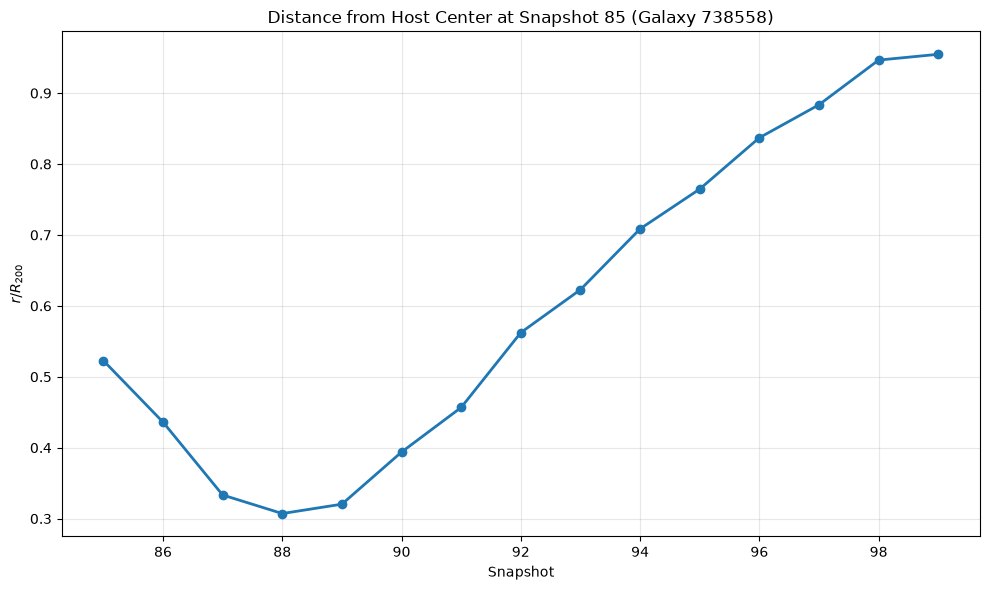

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    df["snap"],
    df["r_R200"],
    marker="o",
    linewidth=2
)

plt.xlabel("Snapshot")
plt.ylabel(r"$r/R_{200}$")
plt.title("Distance from Host Center at Snapshot 85 (Galaxy 738558)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()